<a href="https://colab.research.google.com/github/engSalah-dot/neural-trainer/blob/master/california_housing%20Training%20by%20neural%20network%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Building a Regression MLP Using the Sequential API
#pip install tensorflow
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [2]:
# The House Prices Dataset
housing = fetch_california_housing()
print("Examples = ",housing.data.shape ," Labels = ", housing.target.shape)


Examples =  (20640, 8)  Labels =  (20640,)


In [3]:
X = housing.data
Y = housing.target

print("Example 0 : ",housing.data[0])
print("\nLabel 0 : ",housing.target[0])


Example 0 :  [   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]

Label 0 :  4.526


In [5]:
# Dataset to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["price"] = pd.Series(housing.target)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [8]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [7]:
duplicate_rows = df[df.duplicated()]
print("number of duplicate rows : ",duplicate_rows.shape)

number of duplicate rows :  (0, 9)


In [9]:
X_data=df.drop('price',axis=1).values
Y_data=df['price'].values
print(X_data.shape)
print(Y_data.shape)


(20640, 8)
(20640,)


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_data)
X_sts = scaler.transform(X_data)

In [13]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(X_sts, Y_data, test_size= 0.20, random_state=100)
# Val set
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full
                                                      , test_size= 0.10)

print("X_train  = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test   = ",X_test.shape ," y_test = ", y_test.shape)
print("X_valid  = ",X_valid.shape ," y_valid = ", y_valid.shape)


X_train  =  (14860, 8)  y_train =  (14860,)
X_test   =  (4128, 8)  y_test =  (4128,)
X_valid  =  (1652, 8)  y_valid =  (1652,)


In [15]:
# Creating the model using the Sequential API

model = keras.models.Sequential()
model.add(keras.layers.Dense(100, activation="relu", input_shape = X_train.shape[1:]))  # input_dim = 8
model.add(keras.layers.Dense(25, activation=tf.keras.activations.relu))
model.add(keras.layers.Dense(25, activation="relu"))
model.add(keras.layers.Dense(25, activation="relu"))
model.add(keras.layers.Dense(25, activation="relu"))
model.add(keras.layers.Dense(8, activation="relu"))
model.add(keras.layers.Dense(1, activation="relu")) # price > 0, so, relu

# The model’s summary() method displays all the model’s layers
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,592 (21.84 KB)

 Trainable params: 5,592 (21.84 KB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
model.compile(loss="mean_squared_error", optimizer="sgd", metrics=["mae"])

In [17]:
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_valid, y_valid))


Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.1045 - mae: 0.7632 - val_loss: 0.7035 - val_mae: 0.5957
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5694 - mae: 0.5522 - val_loss: 0.5308 - val_mae: 0.5204
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4868 - mae: 0.5020 - val_loss: 0.4704 - val_mae: 0.4912
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4438 - mae: 0.4769 - val_loss: 0.4793 - val_mae: 0.5260
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4228 - mae: 0.4661 - val_loss: 0.4228 - val_mae: 0.4675
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4039 - mae: 0.4536 - val_loss: 0.6103 - val_mae: 0.5457
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3924 - mae: 0.4459 - val_loss: 0.5341 - val_mae: 0.5729
Epoch 8/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3805 - mae: 0.4404 - val_loss: 0.7005 - val_mae: 0.6969
Epoch 9/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [18]:
history.history

{'loss': [1.1045082807540894,
  0.5693996548652649,
  0.48676374554634094,
  0.4437562823295593,
  0.422834575176239,
  0.4038783609867096,
  0.3924172818660736,
  0.38050687313079834,
  0.3749806880950928,
  0.3647463023662567,
  0.37045493721961975,
  0.3551006019115448,
  0.34889841079711914,
  0.34790271520614624,
  0.34816768765449524,
  0.3566089868545532,
  0.342655748128891,
  0.3408766984939575,
  0.33106935024261475,
  0.33245378732681274,
  0.32967880368232727,
  0.3254920542240143,
  0.31696152687072754,
  0.3214802145957947,
  0.316579669713974,
  0.32869523763656616,
  0.30787134170532227,
  0.31116750836372375,
  0.3117433488368988,
  0.3150980770587921,
  0.3082733750343323,
  0.31255510449409485,
  0.3040344715118408,
  0.3095237612724304,
  0.30745384097099304,
  0.300571084022522,
  0.30726370215415955,
  0.29887086153030396,
  0.2945951819419861,
  0.3022499978542328,
  0.302720844745636,
  0.3024277687072754,
  0.2972472608089447,
  0.291496217250824,
  0.292322933

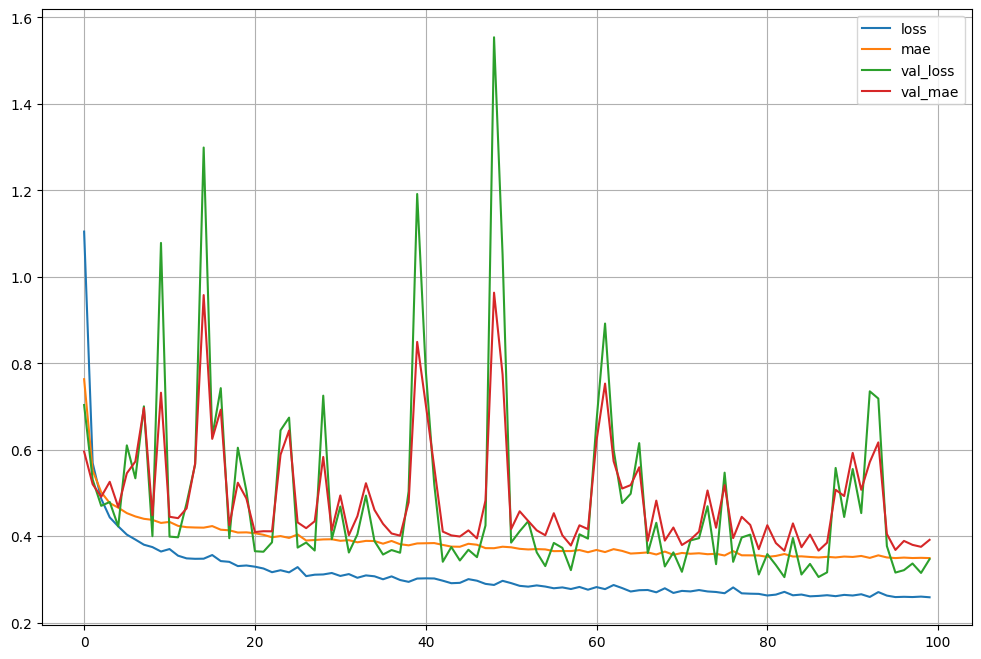

-----------------------------------------------------------------------
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3105 - mae: 0.3735
Loss                   :  0.31049370765686035
Mean Absolute Error     :  0.373517781496048


In [19]:
# plot the learning curves
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(12, 8))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

print("-----------------------------------------------------------------------")
# Evaluate the model
model_evaluate = model.evaluate(X_test, y_test)
print("Loss                   : ",model_evaluate[0])
print("Mean Absolute Error     : ",model_evaluate[1])


In [20]:
predicted = model.predict(X_test)

# Model evaluation
print("Mean Absolute Error    : ", metrics.mean_absolute_error(y_test, predicted))
print("Mean Squared Error     : ", metrics.mean_squared_error(y_test, predicted))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, predicted)))
print("r2_score               : ", metrics.r2_score(y_test, predicted))

print("-----------------------------------------------------------------------")
df_data = pd.DataFrame({"Actual": y_test.flatten(), "Predicted": predicted.flatten()})
print(df_data.head(15))
print("-----------------------------------------------------------------------")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Mean Absolute Error    :  0.3735177281323283
Mean Squared Error     :  0.31049370797133047
Root Mean Squared Error:  0.5572196227443273
r2_score               :  0.7695603827677492
-----------------------------------------------------------------------
    Actual  Predicted
0    2.453   2.400760
1    1.042   1.259539
2    1.462   1.328199
3    1.542   1.146651
4    3.242   2.432481
5    1.411   1.549614
6    2.273   1.942287
7    2.023   2.103117
8    1.702   1.110707
9    3.018   3.274930
10   1.522   1.693571
11   3.081   3.450771
12   4.850   4.184894
13   1.625   1.830030
14   2.250   2.387287
-----------------------------------------------------------------------


In [21]:
model = keras.models.Sequential()

# Encoder - تدريجي مش مرة واحدة
model.add(keras.layers.Dense(128, input_shape=X_train.shape[1:]))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Dense(32))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))

model.add(keras.layers.Dense(16))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))

# Output - linear لأن السعر continuous value
model.add(keras.layers.Dense(1, activation="linear"))

# Adam بدل SGD
model.compile(
    loss="mean_squared_error",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["mae"]
)

# Callbacks مهمة
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,      # زودنا الـ batch size
    validation_data=(X_valid, y_valid),
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 6.0747 - mae: 2.2535 - val_loss: 5.2198 - val_mae: 2.0503 - learning_rate: 0.0010
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.2781 - mae: 1.6052 - val_loss: 3.8558 - val_mae: 1.7406 - learning_rate: 0.0010
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7409 - mae: 1.0985 - val_loss: 2.3188 - val_mae: 1.3082 - learning_rate: 0.0010
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0018 - mae: 0.7831 - val_loss: 1.2376 - val_mae: 0.8782 - learning_rate: 0.0010
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6717 - mae: 0.6018 - val_loss: 0.7551 - val_mae: 0.6203 - learning_rate: 0.0010
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5252 - mae: 0.5185 - val_loss: 0.5641 - val_mae: 0.5176 - learning_rate: 0.0010
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4707 - mae: 0.4900 - val_loss: 0.4931 - val_mae: 0.4818 - learning_rate: 0.0010
Epoch 8/100


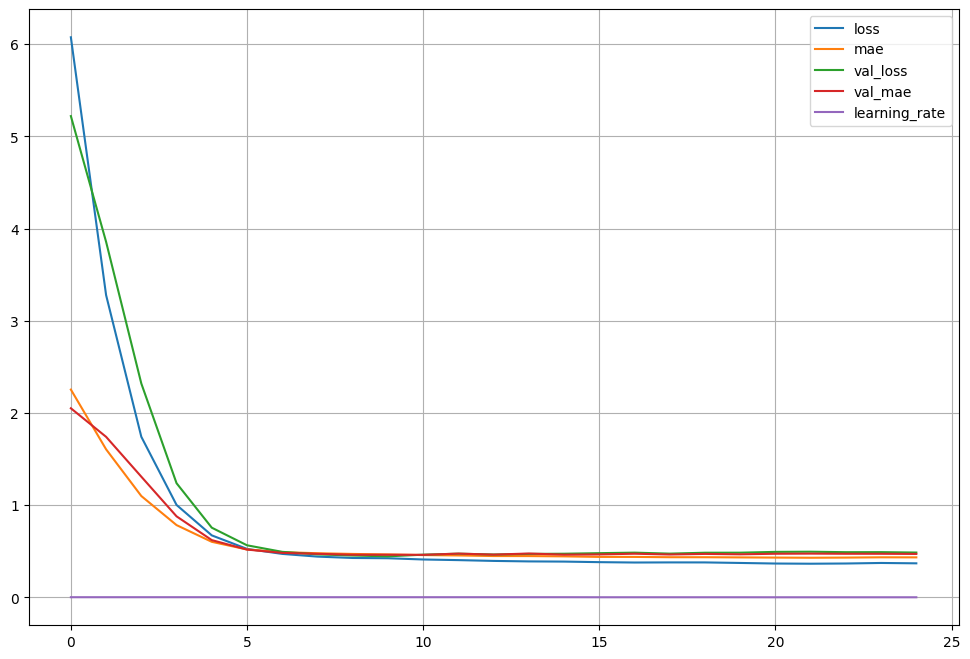

-----------------------------------------------------------------------
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4099 - mae: 0.4419
Loss                   :  0.4099312424659729
Mean Absolute Error     :  0.4419040083885193


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(12, 8))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

print("-----------------------------------------------------------------------")
# Evaluate the model
model_evaluate = model.evaluate(X_test, y_test)
print("Loss                   : ",model_evaluate[0])
print("Mean Absolute Error     : ",model_evaluate[1])


In [ ]:

# الكود بتاعك هنا